In [22]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

import matplotlib.pyplot as plt

In [23]:
import warnings
pd.options.mode.chained_assignment = None
warnings.filterwarnings('ignore')

In [24]:
df = pd.read_csv('source/FReDA4.csv')

In [25]:
# df2 = df.dropna(subset=traits).copy()
# print(df2['Group3'].value_counts())

In [26]:
df = df.rename(columns={
    'Work Status': 'Work_Status',

    'Self-esteem': 'Self_esteem',
    'Life Satisfaction': 'Life_Satisfaction',

    'Relationship Sex': 'Relationship_Sex',
    'Relationship Length': 'Relationship_Length',
    'Age difference': 'Age_Difference',
    'Communication Quality': 'Communication_Quality',
    'Relationship Satisfaction': 'Relationship_Satisfaction',
    'Conflict Management': 'Conflict_Management'
})

In [27]:
mask1 = (
    df.groupby('CoupleId')['Frequency_F']
    .nunique()
    .eq(1)
)

mask2 = (
    df.groupby('CoupleId')['Desire_F']
    .nunique()
    .eq(1)
)

df['Match_Frequency'] = df['CoupleId'].map(
    lambda cid: 'Aligned' if mask1.get(cid, False) else 'Misaligned'
    # lambda cid: 1 if mask1.get(cid, False) else 0
)
df['Match_Frequency_n'] = df['CoupleId'].map(
    # lambda cid: 'Alignment' if mask1.get(cid, False) else 'Disalignment'
    lambda cid: 1 if mask1.get(cid, False) else 0
)

df['Match_Desire'] = df['CoupleId'].map(
    lambda cid: 'Aligned' if mask2.get(cid, False) else 'Misaligned'
    # lambda cid: 1 if mask2.get(cid, False) else 0
)

df['Match_Desire_n'] = df['CoupleId'].map(
    # lambda cid: 'Alignment' if mask2.get(cid, False) else 'Disalignment'
    lambda cid: 1 if mask2.get(cid, False) else 0
)

In [28]:
traits = [
    'Sex',
    'Age',
    'Work_Status',
    'Education',
    'Urbanization',
    'Match_Frequency_n',
    'Match_Desire_n',

    'Extraversion',
    'Agreeableness',
    'Conscientiousness',
    'Openness',
    'Neuroticism',
    'Conservatism',
    'Religiosity',

    'Depressiveness',
    'Loneliness',
    'Self_esteem',
    'Life_Satisfaction',
    'Health',

    'Relationship_Sex',
    'Relationship_Length',
    'Age_Difference',
    'Married',
    'Cohabitation',
    'Kids',
    'Communication_Quality',
    'Relationship_Satisfaction',
    'Conflict_Management',
]

In [29]:
print(len(traits))

28


In [30]:
# 1. (1 = Satisfied, 0 = All others)
df['Is_Satisfied'] = np.where(df['Group3'] == 'Couple Satisfaction', 1, 0)

In [31]:
potential_predictors = traits
significant_predictors = []

In [32]:
for var in potential_predictors:
    # Check bivariate association
    formula = f"Is_Satisfied ~ {var}"

    model = smf.gee(formula,
                    groups=df['CoupleId'],
                    data=df,
                    family=sm.families.Binomial()
                    ).fit()

    # If p-value of the predictor is significant (< 0.05), keep it
    p_val = model.pvalues.iloc[1]
    if p_val < 0.05:
        significant_predictors.append(var)

In [33]:
print('Significant predictors found:', len(significant_predictors))
print(significant_predictors)

Significant predictors found: 21
['Age', 'Work_Status', 'Match_Frequency_n', 'Match_Desire_n', 'Extraversion', 'Agreeableness', 'Conscientiousness', 'Openness', 'Neuroticism', 'Depressiveness', 'Loneliness', 'Self_esteem', 'Life_Satisfaction', 'Health', 'Relationship_Length', 'Married', 'Cohabitation', 'Kids', 'Communication_Quality', 'Relationship_Satisfaction', 'Conflict_Management']


In [34]:
final_formula = "Is_Satisfied ~ " + " + ".join(significant_predictors)

# Using GEE with a Binomial family acts as a logistic regression that adjusts StdErrs for couples
final_model = smf.gee(final_formula,
                      groups=df['CoupleId'],
                      data=df,
                      family=sm.families.Binomial()
                      ).fit()

In [35]:
# 4. Adjusted Odds Ratios (AOR) and 95% Confidence Intervals
results_df = pd.DataFrame({
    'AOR': np.exp(final_model.params),
    'Lower CI': np.exp(final_model.conf_int()[0]),
    'Upper CI': np.exp(final_model.conf_int()[1]),
    'p-value': final_model.pvalues
})

In [36]:
# 1. Create a dictionary to rename the index rows directly
rename_dict = {
    'Self_esteem': 'Self Esteem',
    'Work_Status': 'Work Status',
    'Match_Frequency_n': 'Frequency Alignment',
    'Match_Desire_n': 'Desire Alignment',
    'Life_Satisfaction': 'Life Satisfaction',
    'Conflict_Management': 'Conflict Management',
    'Relationship_Length': 'Relationship Length',
    'Relationship_Satisfaction': 'Relationship Satisfaction',
    'Communication_Quality': 'Communication Quality'
}

results_df = results_df.rename(index=rename_dict)
results_df = results_df.reset_index().rename(columns={'index': 'Variable'})

In [37]:
results_df["err_lower"] = results_df["AOR"] - results_df["Lower CI"]
results_df["err_upper"] = results_df["Upper CI"] - results_df["AOR"]

In [38]:
plot_df = results_df.sort_values('AOR', ascending=True).reset_index(drop=True)

In [39]:
plot_df = plot_df.drop([0]).reset_index(drop=True)

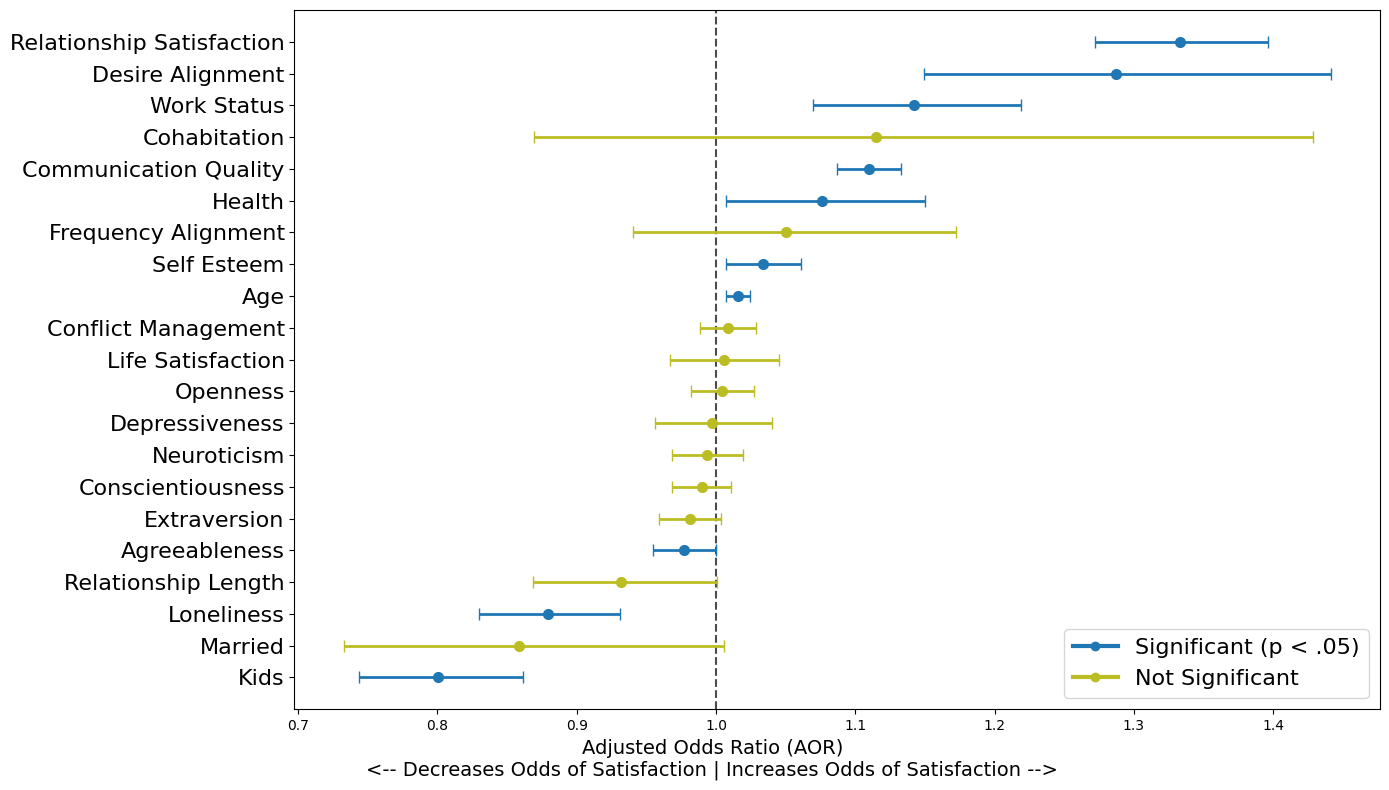

In [41]:
# 2. Set up the plot aesthetics
plt.figure(figsize=(14, 8))
plt.style.use('default')

# 3. Create colors based on significance (p < 0.05)
colors = ['#1f77b4' if p < 0.05 else '#bcbd22' for p in plot_df['p-value']]

for idx, (i, row) in enumerate(plot_df.iterrows()):
    plt.errorbar(
        x=row['AOR'],
        y=i,
        xerr=[[row['err_lower']], [row['err_upper']]],
        fmt='o',
        color=colors[idx],
        ecolor=colors[idx],
        capsize=4,
        markersize=7,
        linewidth=2
    )

plt.axvline(x=1.0, color='black', linestyle='--', alpha=0.7, zorder=0)

plt.yticks(range(len(plot_df)), plot_df['Variable'], fontsize=16)
plt.xlabel(
    "Adjusted Odds Ratio (AOR)\n<-- Decreases Odds of Satisfaction | Increases Odds of Satisfaction -->",
    # "Adjusted Odds Ratio (AOR)",
    x=0.385,
    ha='center',
    fontsize=14)

from matplotlib.lines import Line2D

custom_lines = [Line2D([0], [0], color='#1f77b4', lw=3, marker='o'),
                Line2D([0], [0], color='#bcbd22', lw=3, marker='o')]
plt.legend(custom_lines, ['Significant (p < .05)', 'Not Significant'], loc='lower right', fontsize=16)
plt.tight_layout()

plt.savefig("output/img/regression_stats.png",dpi=300, bbox_inches='tight')
plt.show()